In [4]:
import pandas as pd # import library for handling the dataset(tables)

In [5]:
dataset = pd.read_csv("50_Startups.csv")
# data collection, read the dataset

In [6]:
dataset = pd.get_dummies(dataset, drop_first = True, dtype = int)
# data preprocessing, drop the dummy column 
#convert the classification data into numerical data by nominal and ordinal because python cant handle classification data


In [7]:
dataset.columns #to get the columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Florida', 'State_New York'],
      dtype='object')

In [8]:
#split the input and output
independent = dataset [['R&D Spend', 'Administration', 'Marketing Spend', 
       'State_Florida', 'State_New York']]
dependent = dataset [['Profit']]

In [9]:
#split the train and test
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(independent, dependent, test_size = 0.30, random_state = 0)

In [18]:
#Model creation from the training set
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(criterion = 'absolute_error', splitter = 'best')
regressor = regressor.fit(x_train, y_train)

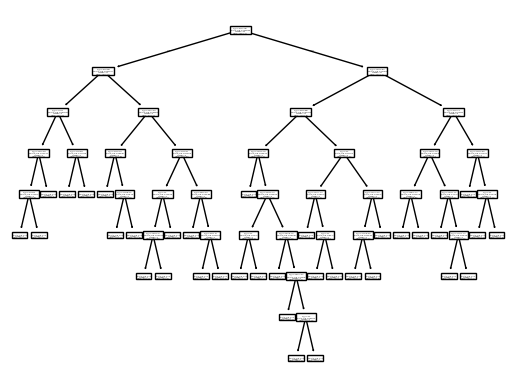

In [19]:
import matplotlib.pyplot as plt #plotting module
from sklearn import tree #tree module for visulaize the decision tree
tree.plot_tree(regressor) #create a graphical representation of trained decision tree 
plt.show() #show the decision tree

In [20]:
y_pred = regressor.predict(x_test) #regressor is trained model of dataset, predict handle the input, x-test is test inpu


In [21]:
from sklearn.metrics import r2_score #evaluation metrics
r_score = r2_score(y_test, y_pred)
r_score

0.9382046418473565

In [22]:
import pickle #save the model
filename = "finalized_model_Svm.sav"
pickle.dump(regressor, open(filename, 'wb'))


In [23]:
loaded_model = pickle.load(open("finalized_model_Svm.sav", 'rb'))
result = loaded_model.predict([[13, 14, 5, 0, 1]]) #5 input('R&D Spend', 'Administration', 'Marketing Spend','State_Florida', 'State_New York' )
result #profit of 5 input values 

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([42559.73])